In [4]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [5]:
import numpy as np
import pandas as pd

np.random.seed(42)  # keeps results reproducible every time you re-run

n_normal = 800

temp = np.random.normal(loc=25, scale=3, size=n_normal)       # normal ~25°C
humidity = np.random.normal(loc=50, scale=8, size=n_normal)   # normal ~50%
gas = np.random.normal(loc=150, scale=25, size=n_normal)      # normal ~150ppm

print(temp[:5])
print(humidity[:5])
print(gas[:5])

[26.49014246 24.5852071  26.94306561 29.56908957 24.29753988]
[57.50627045 45.87164217 50.76896622 46.30179769 46.52403018]
[145.42758897 184.37191048 133.85089552 130.02019983 137.93141195]


In [6]:
n_anomaly = 200

temp_anom = np.random.normal(loc=45, scale=5, size=n_anomaly)      # spiking hot
humidity_anom = np.random.normal(loc=15, scale=10, size=n_anomaly) # abnormally dry
gas_anom = np.random.normal(loc=400, scale=40, size=n_anomaly)     # gas spike

humidity_anom = np.clip(humidity_anom, 0, 100)  # humidity can't go below 0% or above 100%

print(temp_anom[:5])
print(humidity_anom[:5])
print(gas_anom[:5])

[41.39131223 45.88410436 42.26659958 43.64172445 53.36726045]
[ 0.         21.19711446  8.64637611  3.10333341  8.7565461 ]
[407.35338065 507.72134656 413.99200098 359.83781613 396.18143012]


In [7]:
# Classification labels: 0 = NORMAL, 1 = ANOMALY
label_normal = np.zeros(n_normal)
label_anomaly = np.ones(n_anomaly)

# Combine normal + anomaly into single arrays
temp_all = np.concatenate([temp, temp_anom])
humidity_all = np.concatenate([humidity, humidity_anom])
gas_all = np.concatenate([gas, gas_anom])
class_label = np.concatenate([label_normal, label_anomaly])

print("Total samples:", len(temp_all))
print("Normal count:", int((class_label == 0).sum()))
print("Anomaly count:", int((class_label == 1).sum()))

Total samples: 1000
Normal count: 800
Anomaly count: 200


In [8]:
# Risk index = weighted combination of the 3 sensors, plus some random noise
risk_index = (
    0.4 * (temp_all - 25) +
    0.3 * (50 - humidity_all) +
    0.5 * (gas_all - 150) / 10
) + np.random.normal(0, 2, size=len(temp_all))

# Keep it in a sensible 0-100 range
risk_index = np.clip(risk_index + 30, 0, 100)

print(risk_index[:5])
print("Min:", risk_index.min(), "Max:", risk_index.max(), "Mean:", risk_index.mean())

[24.29994018 31.07041569 28.91187009 35.71348183 31.27148374]
Min: 18.876049241671115 Max: 72.27245893471613 Mean: 35.99308279291971


In [9]:
df = pd.DataFrame({
    'temperature': temp_all,
    'humidity': humidity_all,
    'gas': gas_all,
    'risk_index': risk_index,
    'anomaly_label': class_label
})

# Shuffle the rows so normal/anomaly aren't grouped together in order
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

df.head(10)

,temperature,humidity,gas,risk_index,anomaly_label
0,26.630081,54.237542,169.615107,25.374983,0.0
1,27.948073,45.738393,151.244342,32.201204,0.0
2,19.477377,49.779881,167.470711,27.301161,0.0
3,23.279014,48.892352,160.918464,29.469745,0.0
4,21.626074,44.456758,130.931881,28.553844,0.0
5,27.807035,42.900063,166.657813,36.469101,0.0
6,22.031186,66.449657,185.490075,23.983435,0.0
7,22.277309,54.462482,124.945314,22.824172,0.0
8,47.360011,20.532512,407.764305,60.281685,1.0
9,22.650240,41.830137,123.657940,32.097051,0.0


In [10]:
print(df.describe())
print(df['anomaly_label'].value_counts())

       temperature     humidity          gas   risk_index  anomaly_label
count  1000.000000  1000.000000  1000.000000  1000.000000      1000.0000
mean     29.046040    43.673560   200.283466    35.993083         0.2000
std       8.847685    16.258715   103.923472    12.954846         0.4002
min      15.276198     0.000000    74.512196    18.876049         0.0000
25%      23.441850    38.607586   139.107219    28.152087         0.0000
50%      25.897798    48.216453   158.156764    30.944046         0.0000
75%      29.623033    54.477780   186.509491    35.047863         0.0000
max      59.926295    70.813465   557.049508    72.272459         1.0000
anomaly_label
0.0    800
1.0    200
Name: count, dtype: int64


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/EnviroSense_Project/docs/day1_scatter.png'

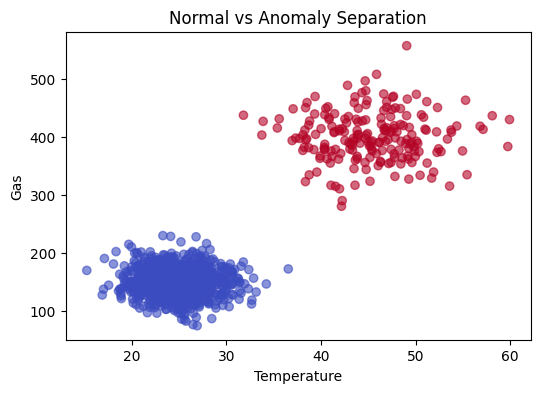

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['temperature'], df['gas'], c=df['anomaly_label'], cmap='coolwarm', alpha=0.6)
plt.xlabel('Temperature')
plt.ylabel('Gas')
plt.title('Normal vs Anomaly Separation')
plt.savefig('/content/drive/MyDrive/EnviroSense_Project/docs/day1_scatter.png')
plt.show()

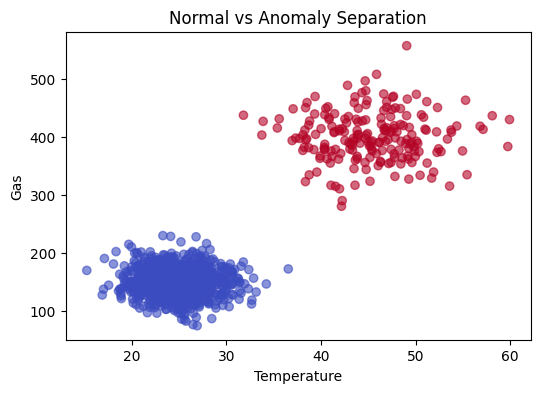

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.scatter(df['temperature'], df['gas'], c=df['anomaly_label'], cmap='coolwarm', alpha=0.6)
plt.xlabel('Temperature')
plt.ylabel('Gas')
plt.title('Normal vs Anomaly Separation')
plt.savefig('/content/drive/MyDrive/EnviroSense_Project/docs/day1_scatter.png')
plt.show()


In [13]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df, test_size=0.2, random_state=42, stratify=df['anomaly_label']
)

train_df.to_csv('/content/drive/MyDrive/EnviroSense_Project/data/train.csv', index=False)
test_df.to_csv('/content/drive/MyDrive/EnviroSense_Project/data/test.csv', index=False)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print(train_df['anomaly_label'].value_counts())
print(test_df['anomaly_label'].value_counts())

Train shape: (800, 5)
Test shape: (200, 5)
anomaly_label
0.0    640
1.0    160
Name: count, dtype: int64
anomaly_label
0.0    160
1.0     40
Name: count, dtype: int64


## Dataset Documentation — EnviroSense

**Type:** Synthetic dataset generated via NumPy Gaussian sampling (`np.random.normal`),
due to the 1-week project timeline and no physical hardware access.

**Sensors (3 inputs):**
- Temperature (°C) — normal ~25°C (σ=3), anomaly ~45°C (σ=5)
- Humidity (%) — normal ~50% (σ=8), anomaly ~15% (σ=10), clipped to [0,100]
- Gas (ppm) — normal ~150ppm (σ=25), anomaly ~400ppm (σ=40)

**Size:** 1000 total samples — 800 normal, 200 anomaly (80:20 ratio,
reflecting that anomalies are rare events in real systems)

**Targets:**
- `risk_index` (regression) — weighted formula of the 3 sensors + Gaussian
  noise (σ=2), clipped to [0,100]
- `anomaly_label` (classification) — 0 = NORMAL, 1 = ANOMALY

**Split:** 80% train (800 rows) / 20% test (200 rows), stratified by
`anomaly_label` to preserve class ratio in both sets.

**Note:** `humidity`/`gas` can be reinterpreted as `vibration`/`current`
for the equipment-monitoring framing — same underlying feature structure
serves both use cases described in the project name.